In [1]:
import pandas as pd
housing= pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [2]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


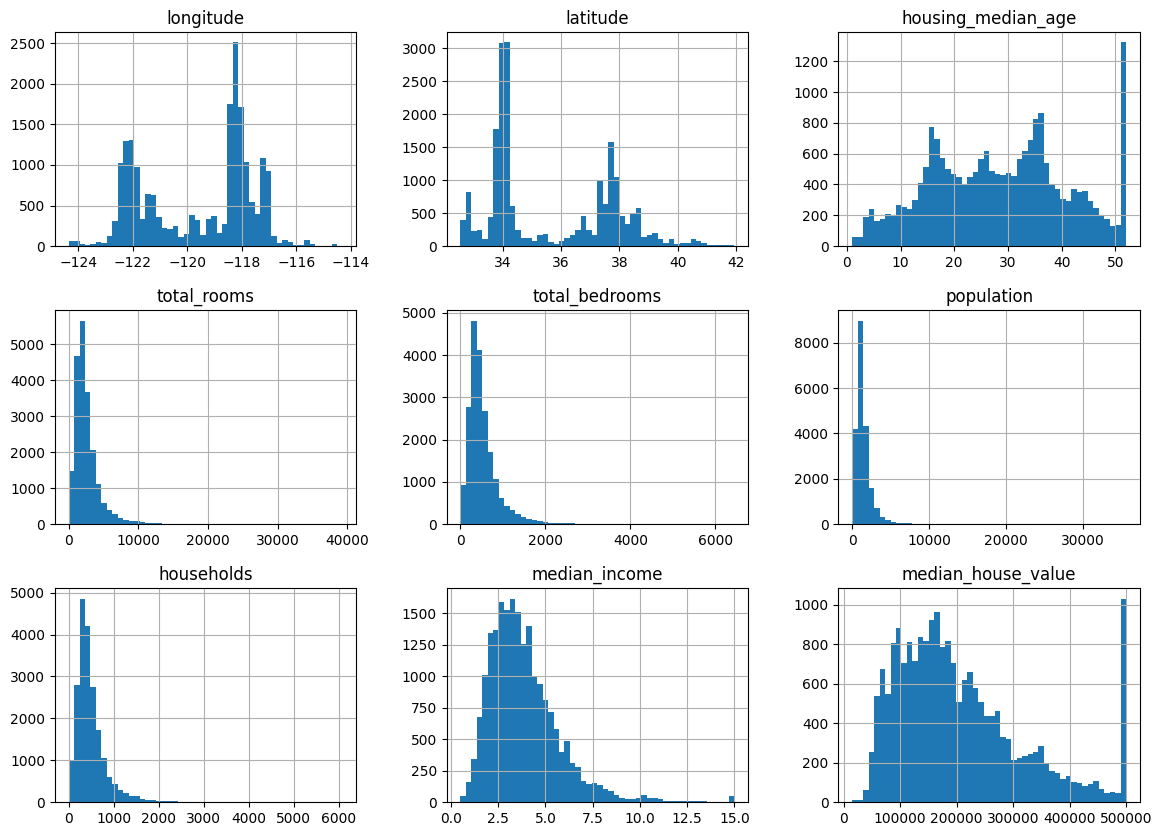

In [9]:
housing.hist(figsize=(14,10), bins=50)
plt.show()

In [17]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
from sklearn.model_selection import train_test_split

housing = pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv"
)

train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_set))
print("Test size:", len(test_set))

Train size: 16512
Test size: 4128


In [15]:
import numpy as np

housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

print("Stratified train:", len(strat_train_set))
print("Stratified test:", len(strat_test_set))

Stratified train: 16512
Stratified test: 4128


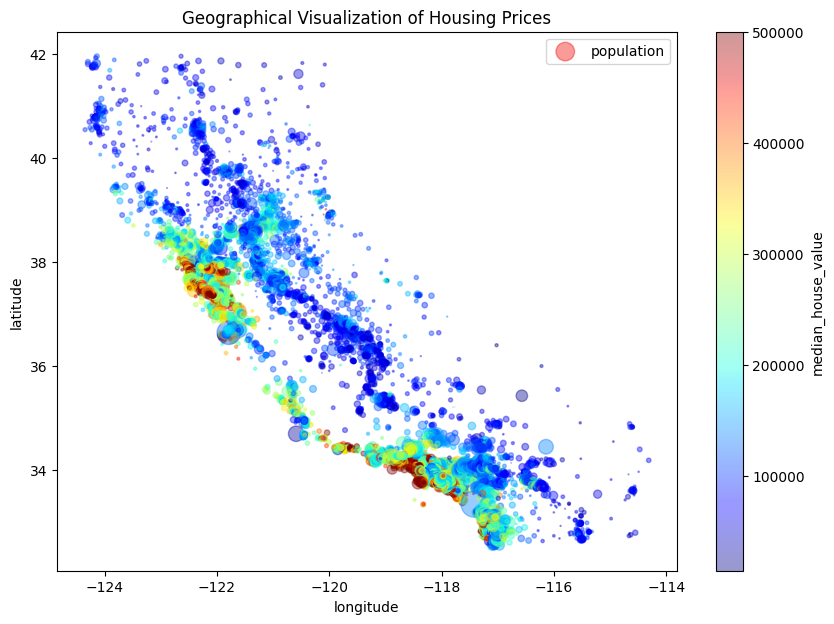

In [16]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv"
)

housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"]/100,
    label="population",
    figsize=(10,7),
    c="median_house_value",
    cmap="jet",
    colorbar=True
)

plt.title("Geographical Visualization of Housing Prices")
plt.legend()
plt.show()

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


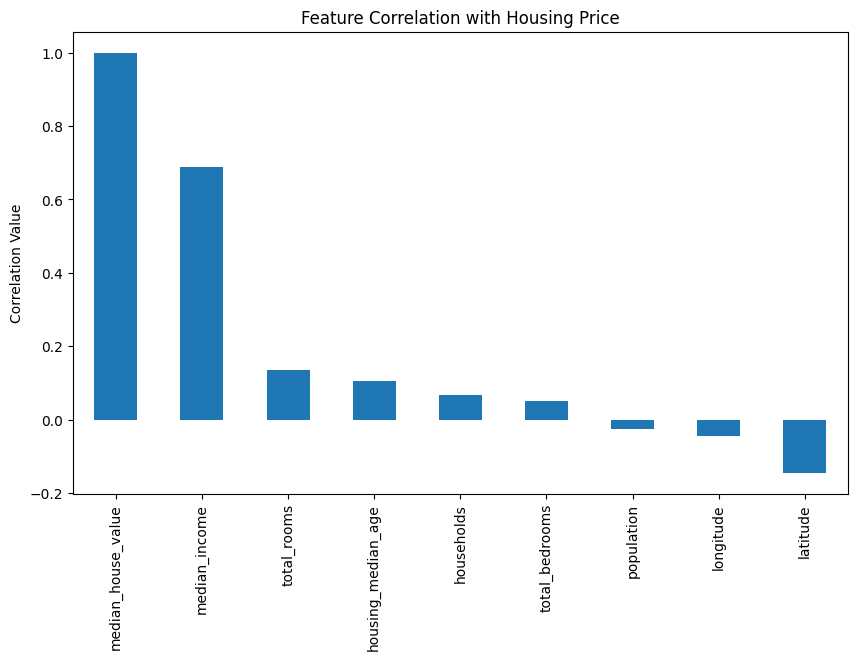

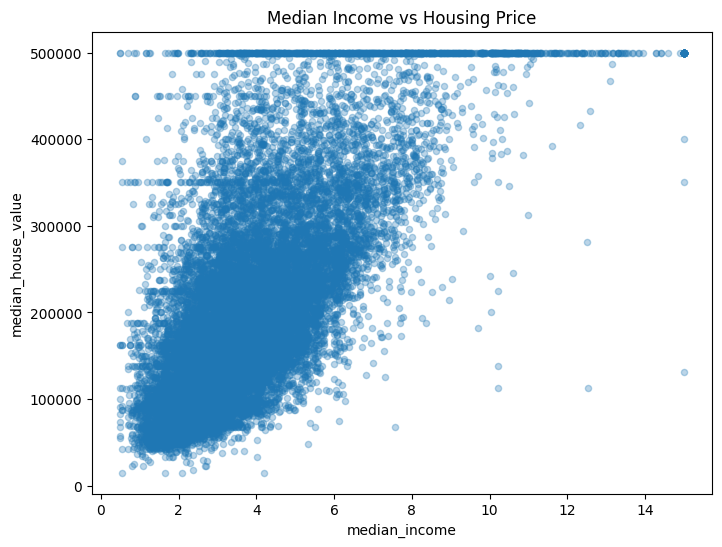

In [21]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv"
)

corr_matrix = housing.corr(numeric_only=True)

price_corr = corr_matrix["median_house_value"].sort_values(ascending=False)
print(price_corr)

price_corr.plot(kind="bar", figsize=(10,6))
plt.title("Feature Correlation with Housing Price")
plt.ylabel("Correlation Value")
plt.show()

housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.3,
    figsize=(8,6)
)

plt.title("Median Income vs Housing Price")
plt.show()



median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


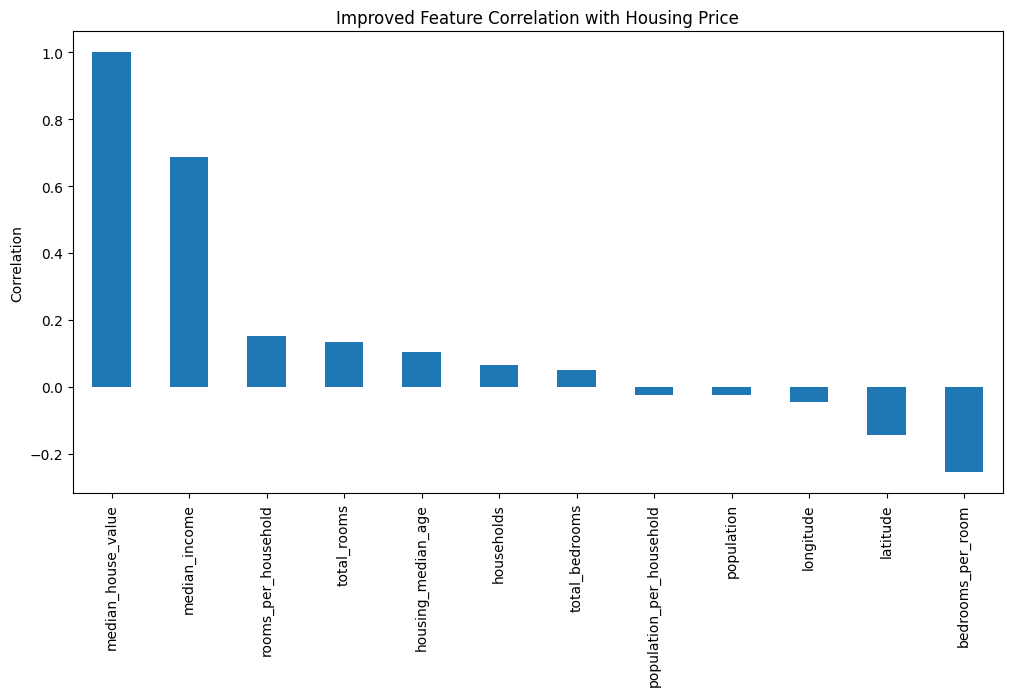

In [23]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv"
)

housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]
corr_matrix = housing.corr(numeric_only=True)

new_corr = corr_matrix["median_house_value"].sort_values(ascending=False)
print(new_corr)
new_corr.plot(kind="bar", figsize=(12,6))
plt.title("Improved Feature Correlation with Housing Price")
plt.ylabel("Correlation")
plt.show()

In [24]:
housing.isnull().sum()
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="median")

housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

housing_num_clean = pd.DataFrame(
    imputer.transform(housing_num),
    columns=housing_num.columns
)
housing_cat = housing[["ocean_proximity"]]

housing_encoded = pd.get_dummies(housing_cat, drop_first=True)
housing_num_clean["population"] = housing_num_clean["population"].clip(
    upper=housing_num_clean["population"].quantile(0.99)
)
housing_clean = pd.concat(
    [housing_num_clean, housing_encoded],
    axis=1
)

housing_clean.head()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
housing_scaled = scaler.fit_transform(housing_clean)

In [25]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd

housing = pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv"
)

housing_encoded = pd.get_dummies(
    housing,
    columns=["ocean_proximity"]
)

print(housing_encoded.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                      False                   False                   False   
1   

In [26]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# select numeric features
housing_num = housing.select_dtypes(include=["float64", "int64"])

# scale features
scaler = StandardScaler()
housing_scaled = scaler.fit_transform(housing_num)

print(housing_scaled[:5])

[[-1.32783522  1.05254828  0.98214266 -0.8048191  -0.97032521 -0.9744286
  -0.97703285  2.34476576  2.12963148]
 [-1.32284391  1.04318455 -0.60701891  2.0458901   1.34827594  0.86143887
   1.66996103  2.33223796  1.31415614]
 [-1.33282653  1.03850269  1.85618152 -0.53574589 -0.82556097 -0.82077735
  -0.84363692  1.7826994   1.25869341]
 [-1.33781784  1.03850269  1.85618152 -0.62421459 -0.71876767 -0.76602806
  -0.73378144  0.93296751  1.16510007]
 [-1.33781784  1.03850269  1.85618152 -0.46240395 -0.61197437 -0.75984669
  -0.62915718 -0.012881    1.17289952]]


In [27]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# column indices (numeric part)
rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]

        return np.c_[
            X,
            rooms_per_household,
            population_per_household,
            bedrooms_per_room
        ]
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("scaler", StandardScaler()),
])
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder())
])
from sklearn.compose import ColumnTransformer
import pandas as pd

housing = pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv"
)

num_attribs = housing.drop("ocean_proximity", axis=1).columns
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])
housing_prepared = full_pipeline.fit_transform(housing)

print(housing_prepared[:5])

[[-1.32783522  1.05254828  0.98214266 -0.8048191  -0.97247648 -0.9744286
  -0.97703285  2.34476576  2.12963148  0.62855945 -0.04959654 -1.02998783
   0.          0.          0.          1.          0.        ]
 [-1.32284391  1.04318455 -0.60701891  2.0458901   1.35714343  0.86143887
   1.66996103  2.33223796  1.31415614  0.32704136 -0.09251223 -0.8888972
   0.          0.          0.          1.          0.        ]
 [-1.33282653  1.03850269  1.85618152 -0.53574589 -0.82702426 -0.82077735
  -0.84363692  1.7826994   1.25869341  1.15562047 -0.02584253 -1.29168566
   0.          0.          0.          1.          0.        ]
 [-1.33781784  1.03850269  1.85618152 -0.62421459 -0.71972345 -0.76602806
  -0.73378144  0.93296751  1.16510007  0.15696608 -0.0503293  -0.4496128
   0.          0.          0.          1.          0.        ]
 [-1.33781784  1.03850269  1.85618152 -0.46240395 -0.61242263 -0.75984669
  -0.62915718 -0.012881    1.17289952  0.3447108  -0.08561576 -0.63908657
   0.      